# Collector Missing Data Spots

Lists collector polling gaps and estimates missed polls and rows.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "collector_missing_data_spots",
    PROJECT_ROOT / "analysis" / "collector-missing-data-spots.py",
)
missing_data = importlib.util.module_from_spec(spec)
spec.loader.exec_module(missing_data)

DB = PROJECT_ROOT / "data" / "foli.db"
SOURCE = None
LIMIT = 20
MIN_OBSERVATIONS = 1
GAP_MULTIPLIER = 2.0
MIN_MISSING_MINUTES = 0.0

In [2]:
class Args:
    db = DB
    source = SOURCE
    limit = LIMIT
    min_observations = MIN_OBSERVATIONS
    gap_multiplier = GAP_MULTIPLIER
    min_missing_minutes = MIN_MISSING_MINUTES

polls = missing_data.load_polls(Args)
spots = missing_data.build_missing_spots(polls, GAP_MULTIPLIER, MIN_MISSING_MINUTES)
summary = missing_data.summarize_missing_spots(spots, polls)
summary

,source,poll_count,success_count,failed_count,missing_spot_count,total_missing_min,largest_missing_min,estimated_missed_polls,estimated_missed_rows
2,siri_vm,42556,42454,102,25,216.23,47.77,432.42,57521.45
1,siri_alerts,4310,4297,13,3,55.44,34.15,11.08,144.57
0,gtfs,3,3,0,0,0.00,0.00,0.00,0.00


In [3]:
spots.head(LIMIT)

,source,gap_start_utc,gap_end_utc,gap_min,expected_cadence_seconds,missing_min,estimated_missed_polls,estimated_missed_rows,failed_attempt_count,next_success_status
11,siri_vm,2026-04-28T02:40:08+00:00,2026-04-28T03:28:24+00:00,48.27,30.0,47.77,95.53,12707.66,13,OK
27,siri_vm,2026-05-08T08:58:16+00:00,2026-05-08T09:34:17+00:00,36.02,30.0,35.52,71.03,9448.72,0,OK
2,siri_alerts,2026-05-08T08:55:20+00:00,2026-05-08T09:34:29+00:00,39.15,300.0,34.15,6.83,89.06,0,OK
5,siri_vm,2026-04-24T10:36:16+00:00,2026-04-24T10:55:12+00:00,18.93,30.0,18.43,36.87,4903.93,7,OK
24,siri_vm,2026-05-07T07:16:36+00:00,2026-05-07T07:30:32+00:00,13.93,30.0,13.43,26.87,3573.75,6,OK
0,siri_alerts,2026-04-24T10:35:49+00:00,2026-04-24T10:53:59+00:00,18.17,300.0,13.17,2.63,34.34,6,OK
4,siri_vm,2026-04-23T23:59:42+00:00,2026-04-24T00:08:25+00:00,8.72,30.0,8.22,16.43,2185.93,5,OK
1,siri_alerts,2026-05-07T07:15:44+00:00,2026-05-07T07:28:51+00:00,13.12,300.0,8.12,1.62,21.17,5,OK
8,siri_vm,2026-04-26T00:00:03+00:00,2026-04-26T00:08:20+00:00,8.28,30.0,7.78,15.57,2070.65,5,OK
7,siri_vm,2026-04-25T00:00:19+00:00,2026-04-25T00:08:35+00:00,8.27,30.0,7.77,15.53,2066.21,5,OK


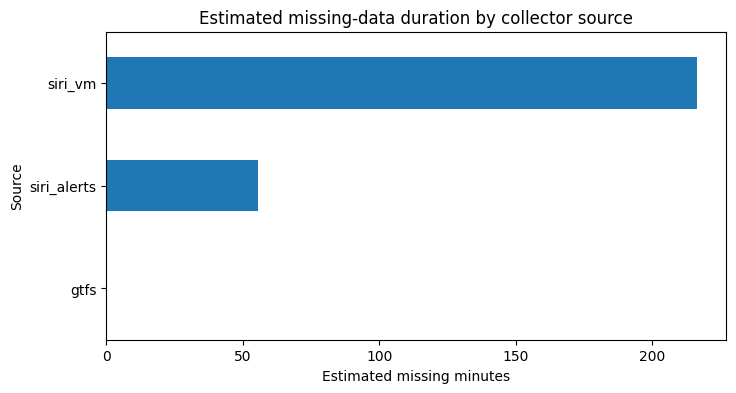

In [4]:
if not summary.empty:
    ax = summary.sort_values("total_missing_min").plot.barh(
        x="source",
        y="total_missing_min",
        legend=False,
        figsize=(8, 4),
        title="Estimated missing-data duration by collector source",
    )
    ax.set_xlabel("Estimated missing minutes")
    ax.set_ylabel("Source")